# Determinants as Signed Area

### An interactive 60–90 minute tutorial

For a matrix whose columns are vectors

$$
A=[\mathbf u\ \mathbf v]
=\begin{bmatrix}u_x&v_x\\u_y&v_y\end{bmatrix},
\qquad \det A=u_xv_y-u_yv_x,
$$

the determinant is the **signed area scale factor** of the linear transformation $\mathbf x\mapsto A\mathbf x$.

By the end, you will be able to:

- read $|\det A|$ as area scaling and the sign as orientation;
- predict how elementary row and column operations affect a determinant;
- connect determinants with composition, inverses, singularity, and conditioning;
- test all ten standard determinant properties numerically, without mistaking experiments for proofs.

> **How to use this notebook.** First predict what will happen, then move the sliders. Static snapshots are included so the story remains readable when widgets are unavailable.

## Setup

This notebook uses only NumPy, Matplotlib, and ipywidgets. In Google Colab, the small compatibility block enables the widget manager. Run the notebook from top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
TOL = 1e-10

BLUE, ORANGE, GREEN, RED, PURPLE, GRAY = (
    "#2563eb", "#f59e0b", "#10b981", "#dc2626", "#7c3aed", "#64748b"
)

## The geometric model

The columns $\mathbf u$ and $\mathbf v$ are the images of the standard basis vectors $\mathbf e_1$ and $\mathbf e_2$. The unit square has ordered vertices

$$0,\quad \mathbf e_1,\quad \mathbf e_1+\mathbf e_2,\quad \mathbf e_2,$$

so its image has ordered vertices

$$0,\quad \mathbf u,\quad \mathbf u+\mathbf v,\quad \mathbf v.$$

The geometric area is $|\det A|$. A positive determinant preserves counterclockwise orientation; a negative one reverses it. A zero determinant collapses the square into a line or a point.

The code expression `A @ points` applies $A$ to every point stored as a column. Everything else below is plotting infrastructure shared by the experiments.

In [2]:
SQUARE = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]], dtype=float)
MARKER = np.array([[0.15, 0.42, 0.15, 0.15],
                   [0.12, 0.12, 0.30, 0.12]], dtype=float)

def det2(A):
    A = np.asarray(A, dtype=float)
    return A[0, 0] * A[1, 1] - A[1, 0] * A[0, 1]

def orientation(d, tol=TOL):
    if np.isclose(d, 0.0, atol=tol):
        return "collapsed (singular)"
    return "positive (orientation preserved)" if d > 0 else "negative (orientation reversed)"

def style_axis(ax, limit=4, title=None):
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.axvline(0, color=GRAY, lw=0.8)
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="$x$", ylabel="$y$")
    ax.set_aspect("equal", adjustable="box")
    if title:
        ax.set_title(title)

def draw_polygon(ax, P, color, label, alpha=0.22, lw=2.2, linestyle="-"):
    if abs(np.linalg.det(np.column_stack((P[:, 1]-P[:, 0], P[:, 3]-P[:, 0])))) < TOL:
        ax.plot(P[0], P[1], color=color, lw=3, linestyle=linestyle, label=label)
    else:
        ax.fill(P[0], P[1], color=color, alpha=alpha)
        ax.plot(P[0], P[1], color=color, lw=lw, linestyle=linestyle, label=label)

def draw_map(ax, A, *, limit=4, show_original=True, title=None, labels=True):
    A = np.asarray(A, dtype=float)
    if show_original:
        draw_polygon(ax, SQUARE, GRAY, "unit square", alpha=0.08, lw=1.5, linestyle="--")
    P, M = A @ SQUARE, A @ MARKER
    draw_polygon(ax, P, BLUE, "transformed square")
    ax.plot(M[0], M[1], color=ORANGE, lw=2.2, marker="o", ms=3, label="orientation marker")
    u, v = A[:, 0], A[:, 1]
    ax.quiver([0, 0], [0, 0], [u[0], v[0]], [u[1], v[1]],
              angles="xy", scale_units="xy", scale=1, color=[GREEN, PURPLE], width=0.010)
    if labels:
        ax.text(*(u + 0.10), "$\mathbf{u}$", color=GREEN, weight="bold")
        ax.text(*(v + 0.10), "$\mathbf{v}$", color=PURPLE, weight="bold")
        for name, p in zip(("0", "u", "u+v", "v"), P[:, :4].T):
            ax.annotate(name, p, xytext=(4, 4), textcoords="offset points", fontsize=8)
    style_axis(ax, limit, title)

def matrix_status(A):
    d = det2(A)
    return f"A = {np.array2string(np.asarray(A), precision=2)}\n det(A) = {d:.3f}   area = {abs(d):.3f}\n {orientation(d)}"

def show_widget(callback, controls, columns=1):
    out = widgets.interactive_output(callback, controls)
    boxes = list(controls.values())
    panel = widgets.VBox(boxes) if columns == 1 else widgets.GridBox(
        boxes, layout=widgets.Layout(grid_template_columns=f"repeat({columns}, minmax(190px, 1fr))")
    )
    display(widgets.HBox([panel, out], layout=widgets.Layout(align_items="flex-start")))
    return out

## Explorer A — a general $2\times2$ matrix

**Predict.** Before touching the sliders: what must the columns look like when the determinant is zero?

The asymmetric orange marker and ordered vertex labels make a reflection visible even if you ignore color. Limits stay fixed, so shrinking area cannot be hidden by automatic zoom.

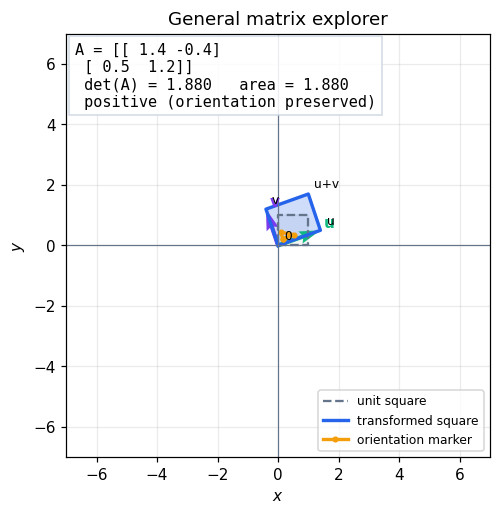

In [3]:
def general_explorer(a=1.4, b=-0.4, c=0.5, d=1.2):
    A = np.array([[a, b], [c, d]])
    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    draw_map(ax, A, limit=7, title="General matrix explorer")
    ax.text(0.02, 0.98, matrix_status(A), transform=ax.transAxes, va="top",
            family="monospace", bbox=dict(facecolor="white", alpha=.88, edgecolor="#cbd5e1"))
    ax.legend(loc="lower right", fontsize=8)
    plt.show()
    plt.close(fig)

# Static default rendering
general_explorer()

In [4]:
general_controls = {
    name: widgets.FloatSlider(value=value, min=-3, max=3, step=.1,
                              description=name, continuous_update=False)
    for name, value in {"a": 1.4, "b": -.4, "c": .5, "d": 1.2}.items()
}
_general_output = show_widget(general_explorer, general_controls, columns=2)

**Numerical check.** For the default matrix, $1.4(1.2)-0.5(-0.4)=1.88$, matching the displayed area. This is evidence for the geometry, while the formula itself gives the exact justification.

**Takeaway.** $|\det A|$ measures area scaling; the sign records orientation.

### A glance at 3D

For a $3\times3$ matrix, the columns span a parallelepiped. Its volume is $|\det A|$, while the sign records whether the ordered basis orientation is preserved or reversed. The same signed-volume idea extends to every dimension.

# 1. Identity: $\det I=1$

**Predict.** What happens to the unit square under $I$?

**Formula and intuition.** $I\mathbf x=\mathbf x$, so neither area nor orientation changes:

$$\det I=1.$$

**Live experiment.** Return the general explorer to $a=d=1$ and $b=c=0$.

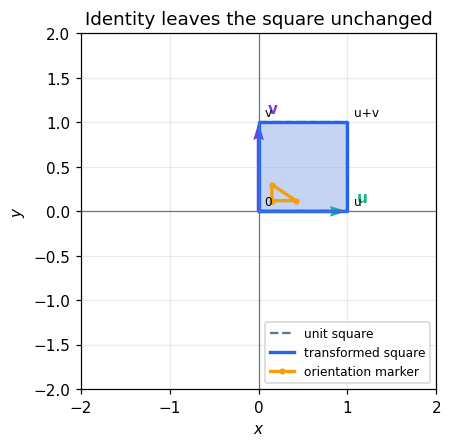

Numerical verification: True  det(I) = 1.0


In [5]:
I = np.eye(2)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_map(ax, I, limit=2, title="Identity leaves the square unchanged")
ax.legend(loc="lower right", fontsize=8)
plt.show(); plt.close(fig)
print("Numerical verification:", np.isclose(np.linalg.det(I), 1.0), " det(I) =", np.linalg.det(I))

**Takeaway.** The identity transformation has signed area scale factor $1$.

# 2. Transpose: $\det A^\top=\det A$

**Predict.** Must $A$ and $A^\top$ produce the same parallelogram, or only the same signed area?

For $A=\begin{bmatrix}a&b\\c&d\end{bmatrix}$,

$$\det A^\top=ad-bc=\det A.$$

The column vectors change from $(a,c),(b,d)$ to $(a,b),(c,d)$, so the shapes can differ.

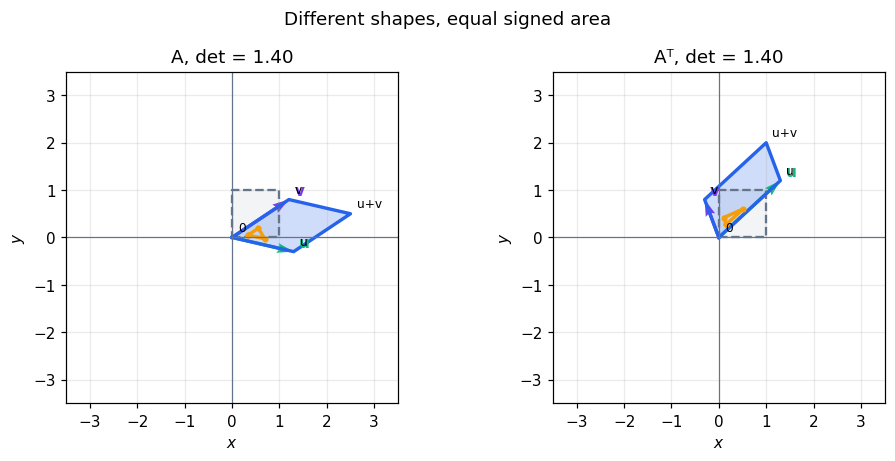

In [6]:
def transpose_experiment(b=1.2, c=-0.3):
    A = np.array([[1.3, b], [c, 0.8]])
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
    draw_map(axes[0], A, limit=3.5, title=f"A, det = {det2(A):.2f}")
    draw_map(axes[1], A.T, limit=3.5, title=f"Aᵀ, det = {det2(A.T):.2f}")
    fig.suptitle("Different shapes, equal signed area")
    plt.tight_layout(); plt.show(); plt.close(fig)

transpose_experiment()

In [7]:
_transpose_output = show_widget(transpose_experiment, {
    "b": widgets.FloatSlider(value=1.2, min=-2, max=2, step=.1, description="b", continuous_update=False),
    "c": widgets.FloatSlider(value=-.3, min=-2, max=2, step=.1, description="c", continuous_update=False)
})

A_check = np.array([[1.3, 1.2], [-.3, .8]])
print("Numerical verification:", np.isclose(np.linalg.det(A_check.T), np.linalg.det(A_check)))

Numerical verification: True


**Takeaway.** Transposition can change the geometry of the columns, but not the signed area scale factor.

# 3. Swapping two rows or columns reverses the sign

**Predict.** Can the identity matrix continuously become the column-swapped identity without passing through determinant zero?

At the endpoints below, the two columns have been swapped, so the ordered orientation reverses. The intermediate matrices form an **interpolation**, not a “partial elementary swap”:

$$A(t)=\begin{bmatrix}1-t&t\\t&1-t\end{bmatrix},\qquad \det A(t)=1-2t.$$

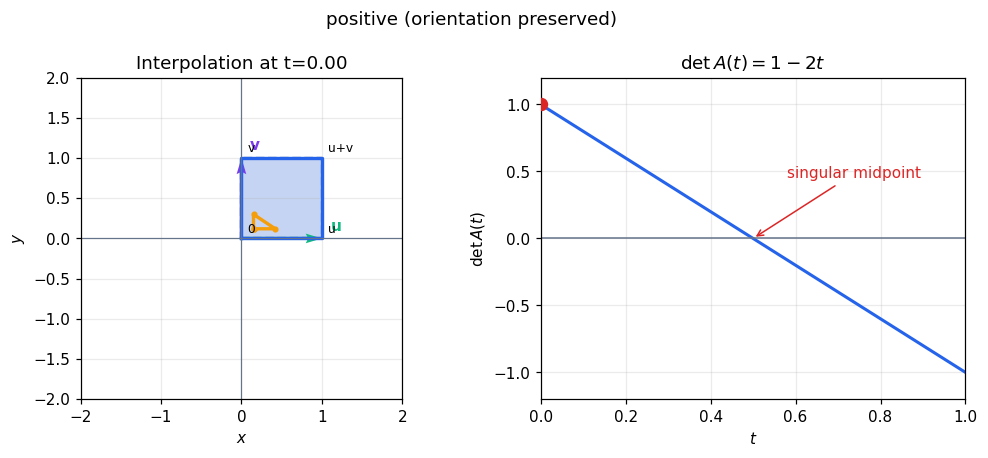

In [8]:
def swap_path(t=0.0):
    A = np.array([[1-t, t], [t, 1-t]])
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
    draw_map(axes[0], A, limit=2, title=f"Interpolation at t={t:.2f}")
    ts = np.linspace(0, 1, 201)
    axes[1].plot(ts, 1-2*ts, color=BLUE, lw=2)
    axes[1].axhline(0, color=GRAY, lw=1)
    axes[1].scatter([t], [1-2*t], color=RED, s=60, zorder=3)
    axes[1].annotate("singular midpoint", (.5, 0), xytext=(.58, .45),
                     arrowprops=dict(arrowstyle="->", color=RED), color=RED)
    axes[1].set(xlim=(0,1), ylim=(-1.2,1.2), xlabel="$t$", ylabel="$\det A(t)$",
                title="$\det A(t)=1-2t$")
    fig.suptitle(f"{orientation(det2(A))}")
    plt.tight_layout(); plt.show(); plt.close(fig)

swap_path(0.0)

In [9]:
_swap_output = show_widget(swap_path, {
    "t": widgets.FloatSlider(value=0, min=0, max=1, step=.02, description="t", continuous_update=False)
})

A0, A1 = np.eye(2), np.array([[0,1],[1,0]])
print("Endpoint determinants:", np.linalg.det(A0), np.linalg.det(A1))
print("Sign reversal verified:", np.isclose(np.linalg.det(A1), -np.linalg.det(A0)))

Endpoint determinants: 1.0 -1.0
Sign reversal verified: True


The determinant formula is alternating: $\det[\mathbf v\ \mathbf u]=-\det[\mathbf u\ \mathbf v]$. The corresponding statement holds for swapping rows.

**Takeaway.** A column or row swap reverses orientation and therefore negates the determinant.

# 4. Scaling one row or column by $c$ multiplies the determinant by $c$

**Predict.** As $t$ moves from positive to negative, what must happen exactly at zero?

Consider

$$A(t)=\begin{bmatrix}1&1\\0&t\end{bmatrix},\qquad \det A(t)=t,\qquad -2\le t\le2.$$

Only the second column's vertical contribution is scaled. At $t=0$, the two columns coincide and the parallelogram is explicitly drawn as a collapsed line.

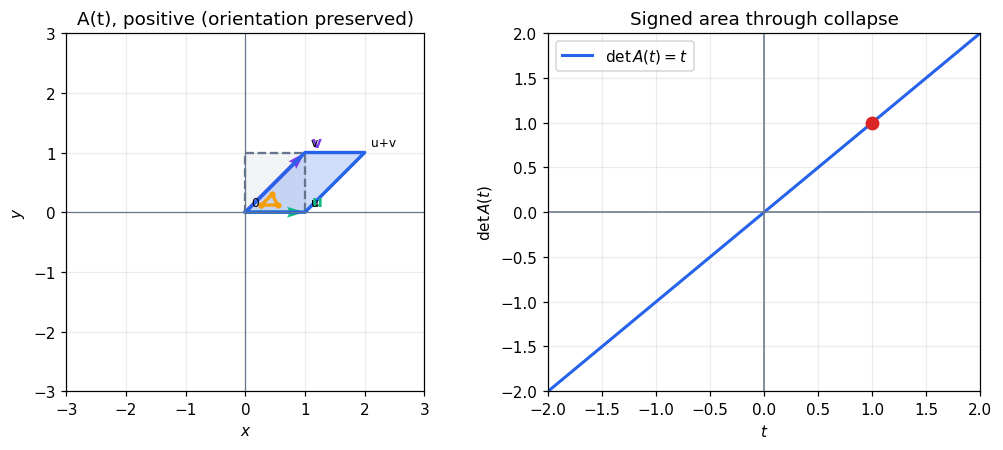

In [10]:
def scaling_collapse(t=1.0):
    A = np.array([[1, 1], [0, t]], dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
    draw_map(axes[0], A, limit=3, title=f"A(t), {orientation(t)}")
    ts = np.linspace(-2, 2, 301)
    axes[1].plot(ts, ts, color=BLUE, lw=2, label="$\det A(t)=t$")
    axes[1].axhline(0, color=GRAY, lw=1); axes[1].axvline(0, color=GRAY, lw=1)
    axes[1].scatter([t], [t], color=RED, s=65, zorder=3)
    axes[1].set(xlim=(-2,2), ylim=(-2,2), xlabel="$t$", ylabel="$\det A(t)$",
                title="Signed area through collapse")
    axes[1].legend()
    plt.tight_layout(); plt.show(); plt.close(fig)

scaling_collapse(1.0)

In [11]:
_scale_output = show_widget(scaling_collapse, {
    "t": widgets.FloatSlider(value=1, min=-2, max=2, step=.1, description="t", continuous_update=False)
})

base = np.array([[1., 1.], [0., 1.]])
for c in (-1.5, 0., 2.):
    scaled = base.copy(); scaled[:, 1] *= c
    print(f"c={c:4.1f}: det(scaled)={np.linalg.det(scaled):5.2f}, "
          f"c det(base)={c*np.linalg.det(base):5.2f}")

c=-1.5: det(scaled)=-1.50, c det(base)=-1.50
c= 0.0: det(scaled)= 0.00, c det(base)= 0.00
c= 2.0: det(scaled)= 2.00, c det(base)= 2.00


The formula is linear in each column, so $\det[\mathbf u,c\mathbf v]=c\det[\mathbf u,\mathbf v]$. The corresponding row rule also holds.

**Takeaway.** Scaling one column or row scales signed area by the same factor, including its sign.

# 5. Adding a multiple of another row or column leaves the determinant unchanged

**Predict.** Which controls below can change area? Which can change orientation?

Use

$$A=R(\theta)S(k)D(s_x,s_y),\qquad
S(k)=\begin{bmatrix}1&k\\0&1\end{bmatrix},\qquad
D=\operatorname{diag}(s_x,s_y).$$

The **rightmost transformation acts first**: scale, then shear, then rotate. Rotation and shear each have determinant $1$, so

$$\det A=\det R\,\det S\,\det D=s_xs_y.$$

Shearing adds a multiple of one coordinate direction to another. In column language, replacing $\mathbf v$ by $\mathbf v+k\mathbf u$ does not change the base-height area:

$$\det[\mathbf u,\mathbf v+k\mathbf u]=\det[\mathbf u,\mathbf v]+k\det[\mathbf u,\mathbf u]=\det[\mathbf u,\mathbf v].$$

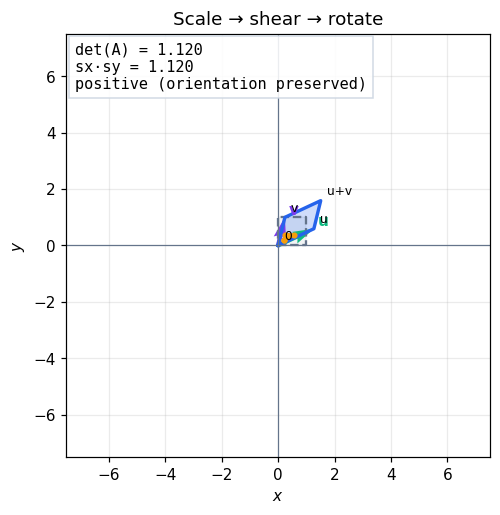

In [12]:
def R(theta):
    q = np.deg2rad(theta)
    return np.array([[np.cos(q), -np.sin(q)], [np.sin(q), np.cos(q)]])

def interpretable(theta=25, k=.8, sx=1.4, sy=.8):
    S = np.array([[1., k], [0., 1.]])
    D = np.diag([sx, sy])
    A = R(theta) @ S @ D
    fig, ax = plt.subplots(figsize=(5.8, 5))
    draw_map(ax, A, limit=7.5, title="Scale → shear → rotate")
    ax.text(.02,.98, f"det(A) = {det2(A):.3f}\nsx·sy = {sx*sy:.3f}\n{orientation(det2(A))}",
            transform=ax.transAxes, va="top", family="monospace",
            bbox=dict(facecolor="white", alpha=.88, edgecolor="#cbd5e1"))
    plt.show(); plt.close(fig)

interpretable()

In [13]:
_transform_output = show_widget(interpretable, {
    "theta": widgets.IntSlider(value=25, min=-180, max=180, step=5, description="angle°", continuous_update=False),
    "k": widgets.FloatSlider(value=.8, min=-2, max=2, step=.1, description="shear k", continuous_update=False),
    "sx": widgets.FloatSlider(value=1.4, min=-2, max=2, step=.1, description="sₓ", continuous_update=False),
    "sy": widgets.FloatSlider(value=.8, min=-2, max=2, step=.1, description="sᵧ", continuous_update=False)
}, columns=2)

for k_test in (-2, 0, 1.7):
    A = np.array([[1., k_test], [0., 1.]])
    print(k_test, np.isclose(np.linalg.det(A), 1.0))

-2 True
0 True
1.7 True


The corresponding row-addition rule also holds, though columns give the most direct vector geometry here.

**Takeaway.** Shear changes shape but preserves signed area; signed axis scales control area and orientation.

# 6. Dependence, determinant zero, and singularity

**Predict.** If one column is a multiple of the other, can the image contain any two-dimensional area?

Dependent columns lie on one line, so the image parallelogram collapses and $\det A=0$. For a square matrix, the converse also holds:

$$\det A=0\quad\Longleftrightarrow\quad A\text{ is singular}.$$

A square matrix is singular exactly when it has no inverse. Move the scaling-through-collapse slider to $t=0$ or the swapping slider to $t=\tfrac12$ for the live experiment.

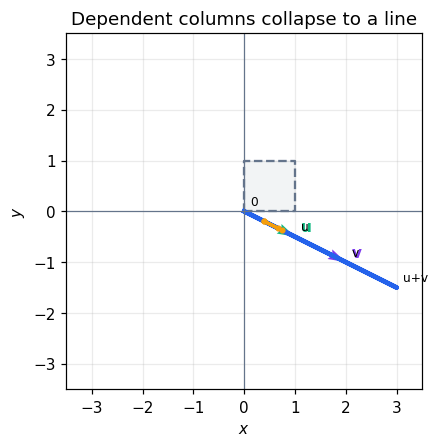

det = 0.0
rank = 1 < 2
singular by determinant test: True


In [14]:
dependent = np.array([[1., 2.], [-.5, -1.]])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_map(ax, dependent, limit=3.5, title="Dependent columns collapse to a line")
plt.show(); plt.close(fig)

print("det =", np.linalg.det(dependent))
print("rank =", np.linalg.matrix_rank(dependent), "<", dependent.shape[0])
print("singular by determinant test:", np.isclose(np.linalg.det(dependent), 0.0))

If $A\mathbf x=0$ has a nonzero solution, the transformation collapses at least one direction; it cannot preserve nonzero $n$-dimensional volume. This gives the geometric core of the equivalence.

**Takeaway.** Zero determinant means dimension has collapsed; for square matrices, that is exactly singularity.

# 7. Triangular matrices: product of the diagonal entries

**Predict.** With diagonal entries fixed, can changing the upper-right entry alter the determinant?

For

$$T=\begin{bmatrix}a&b\\0&d\end{bmatrix},\qquad \det T=ad.$$

The off-diagonal entry shears the parallelogram without changing its base or height. In any dimension, a triangular matrix has

$$\det T=\prod_i t_{ii}.$$

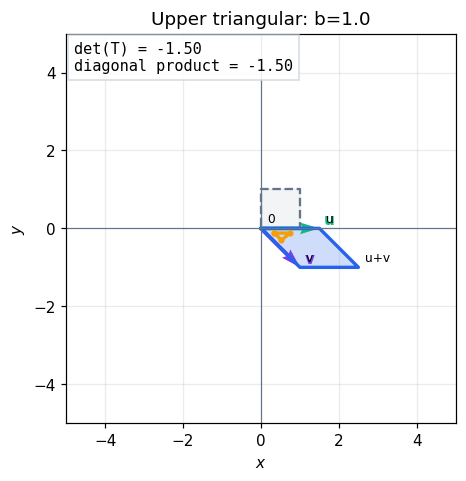

In [15]:
def triangular_experiment(b=1.0):
    T = np.array([[1.5, b], [0., -1.]])
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    draw_map(ax, T, limit=5, title=f"Upper triangular: b={b:.1f}")
    ax.text(.02,.98, f"det(T) = {det2(T):.2f}\ndiagonal product = {-1.5:.2f}",
            transform=ax.transAxes, va="top", family="monospace",
            bbox=dict(facecolor="white", alpha=.88, edgecolor="#cbd5e1"))
    plt.show(); plt.close(fig)

triangular_experiment()

In [16]:
_tri_output = show_widget(triangular_experiment, {
    "b": widgets.FloatSlider(value=1, min=-3, max=3, step=.1, description="off-diag b", continuous_update=False)
})

rng = np.random.default_rng(7)
T5 = np.triu(rng.integers(-4, 5, size=(5, 5))).astype(float)
np.fill_diagonal(T5, [2, -1, 3, 4, -2])
print(T5)
print("det(T5) =", np.linalg.det(T5))
print("diagonal product =", np.prod(np.diag(T5)))
print("match:", np.isclose(np.linalg.det(T5), np.prod(np.diag(T5))))

[[ 2.  1.  2.  4.  1.]
 [ 0. -1. -2. -4. -2.]
 [ 0.  0.  3. -4.  0.]
 [ 0.  0.  0.  4.  0.]
 [ 0.  0.  0.  0. -2.]]
det(T5) = 47.999999999999986
diagonal product = 48.0
match: True


Expanding the determinant of a triangular matrix, every nonzero product must select the diagonal entries. This provides an algebraic justification beyond the experiment.

**Takeaway.** The determinant of a triangular matrix is the product of its diagonal entries; off-diagonal entries do not matter.

# 8. Composition: $\det(AB)=\det A\det B$

**Predict.** If $B$ doubles area and $A$ reverses orientation while tripling area, what does $AB$ do?

$AB\mathbf x=A(B\mathbf x)$: **$B$ acts first**, then $A$. Area scale factors multiply, and orientation signs multiply:

$$\det(AB)=\det A\det B.$$

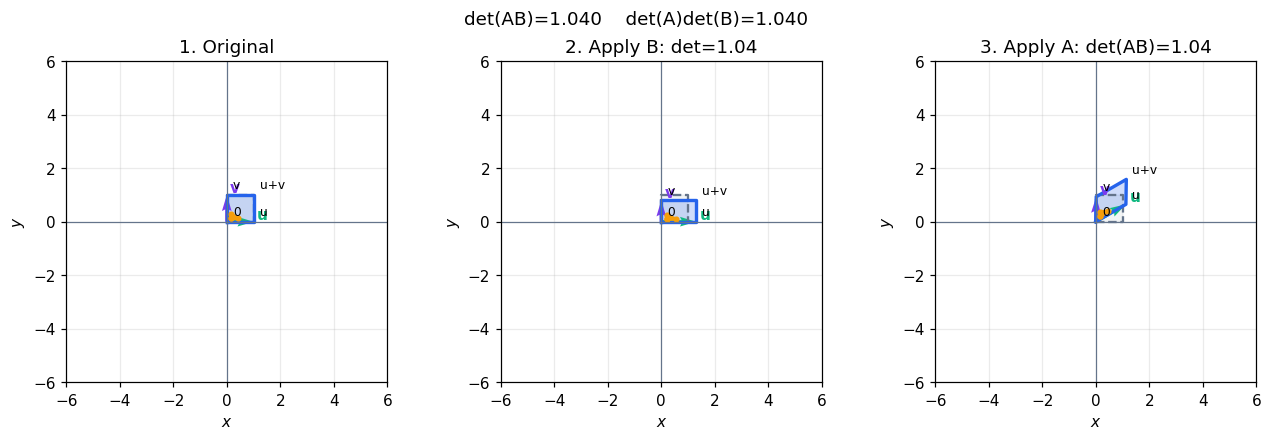

In [17]:
def composition(angle=30, shear=.6, bx=1.3, by=.8):
    B = np.diag([bx, by])
    A = R(angle) @ np.array([[1., shear], [0., 1.]])
    AB = A @ B
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
    draw_map(axes[0], np.eye(2), limit=6, title="1. Original")
    draw_map(axes[1], B, limit=6, title=f"2. Apply B: det={det2(B):.2f}")
    draw_map(axes[2], AB, limit=6, title=f"3. Apply A: det(AB)={det2(AB):.2f}")
    fig.suptitle(f"det(AB)={det2(AB):.3f}    det(A)det(B)={det2(A)*det2(B):.3f}")
    plt.tight_layout(); plt.show(); plt.close(fig)

composition()

In [18]:
_composition_output = show_widget(composition, {
    "angle": widgets.IntSlider(value=30, min=-90, max=90, step=5, description="A rotation°", continuous_update=False),
    "shear": widgets.FloatSlider(value=.6, min=-1.5, max=1.5, step=.1, description="A shear", continuous_update=False),
    "bx": widgets.FloatSlider(value=1.3, min=-2, max=2, step=.1, description="B x-scale", continuous_update=False),
    "by": widgets.FloatSlider(value=.8, min=-2, max=2, step=.1, description="B y-scale", continuous_update=False)
}, columns=2)

A_num = np.array([[2., -1.], [1., 1.]])
B_num = np.array([[.5, 2.], [0., -1.]])
lhs, rhs = np.linalg.det(A_num @ B_num), np.linalg.det(A_num)*np.linalg.det(B_num)
print(f"det(AB)={lhs:.8f}, det(A)det(B)={rhs:.8f}, match={np.isclose(lhs,rhs)}")

det(AB)=-1.50000000, det(A)det(B)=-1.50000000, match=True


Algebraically, applying $B$ scales signed area by $\det B$, and applying $A$ afterward scales it again by $\det A$.

**Takeaway.** Determinants turn matrix composition into multiplication of signed scale factors.

# 9. Inverses: $\det(A^{-1})=1/\det A$

**Predict.** What signed area factor must undo a transformation with determinant $-2$?

Since $AA^{-1}=I$, multiplicativity gives

$$1=\det I=\det A\det(A^{-1}),$$

so for invertible $A$,

$$\det(A^{-1})=\frac1{\det A}.$$

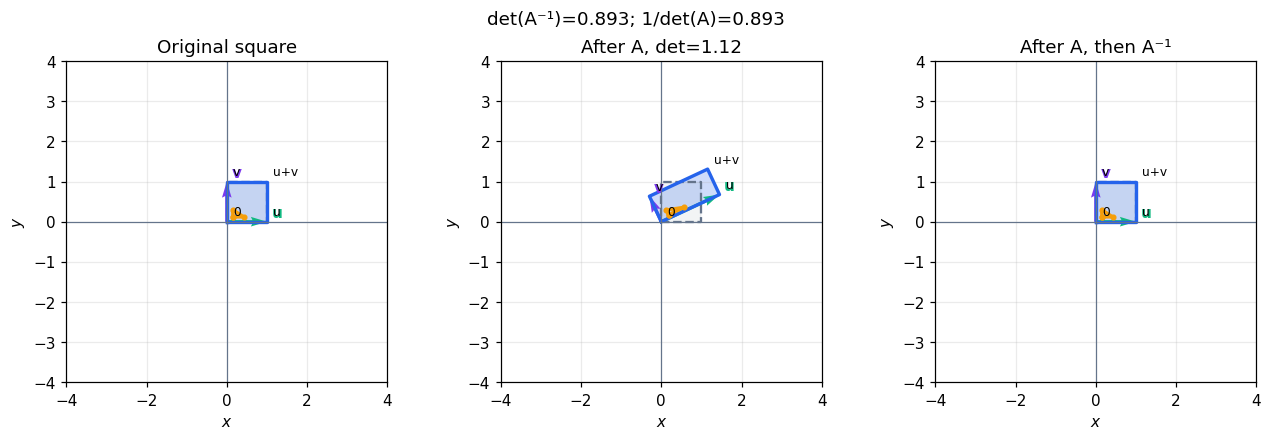

In [19]:
def inverse_experiment(angle=25, sx=1.6, sy=.7):
    A = R(angle) @ np.diag([sx, sy])
    Ainv = np.linalg.inv(A)  # sliders never allow zero scales
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
    draw_map(axes[0], np.eye(2), limit=4, title="Original square")
    draw_map(axes[1], A, limit=4, title=f"After A, det={det2(A):.2f}")
    draw_map(axes[2], Ainv @ A, limit=4, title="After A, then A⁻¹")
    fig.suptitle(f"det(A⁻¹)={det2(Ainv):.3f}; 1/det(A)={1/det2(A):.3f}")
    plt.tight_layout(); plt.show(); plt.close(fig)

inverse_experiment()

In [20]:
_inverse_output = show_widget(inverse_experiment, {
    "angle": widgets.IntSlider(value=25, min=-180, max=180, step=5, description="angle°", continuous_update=False),
    "sx": widgets.FloatSlider(value=1.6, min=.2, max=2.5, step=.1, description="sₓ ≠ 0", continuous_update=False),
    "sy": widgets.FloatSlider(value=.7, min=.2, max=2.5, step=.1, description="sᵧ ≠ 0", continuous_update=False)
})

A_num = np.array([[2., 1.], [1., -1.]])
Ainv_num = np.linalg.inv(A_num)
print("AA⁻¹ ≈ I:", np.allclose(A_num @ Ainv_num, np.eye(2)))
print("det(A⁻¹) ≈ 1/det(A):", np.isclose(np.linalg.det(Ainv_num), 1/np.linalg.det(A_num)))

AA⁻¹ ≈ I: True
det(A⁻¹) ≈ 1/det(A): True


**Takeaway.** The inverse exactly cancels both area scaling and orientation effect.

## Numerical conditioning: near collapse is delicate

This is a companion experiment to singularity and inverses. Consider

$$A_\varepsilon=\begin{bmatrix}1&1\\1&1+\varepsilon\end{bmatrix},\qquad
\varepsilon=10^p,\quad -6\le p\le0.$$

**Predict.** As $p$ decreases, what happens to the angle between the columns and to the sensitivity of solving $A_\varepsilon\mathbf x=\mathbf b$?

Here $\det A_\varepsilon=\varepsilon$. The columns become almost parallel, so one singular value becomes tiny relative to the other. That ratio makes the 2-norm condition number $\kappa_2$ large.

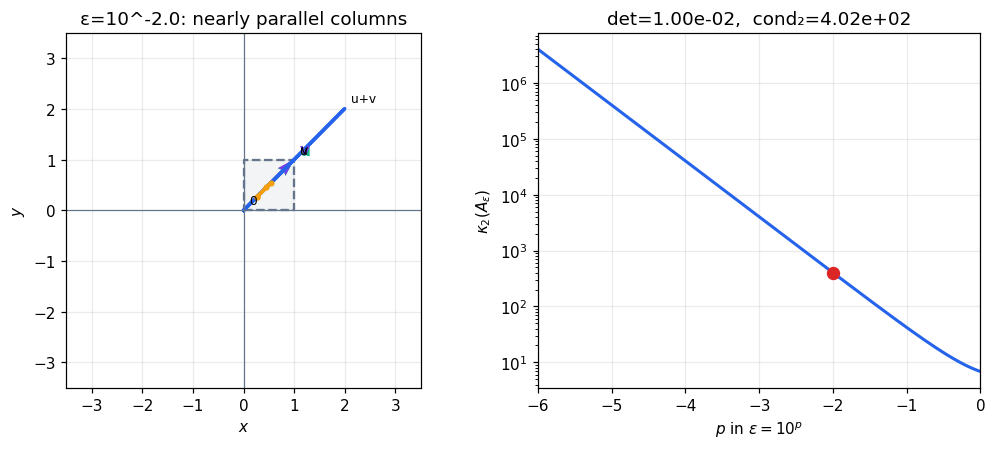

In [21]:
def conditioning_experiment(p=-2.0):
    eps = 10.0**p
    A = np.array([[1., 1.], [1., 1.+eps]])
    cond = np.linalg.cond(A, 2)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
    draw_map(axes[0], A, limit=3.5, title=f"ε=10^{p:.1f}: nearly parallel columns")
    ps = np.linspace(-6, 0, 241)
    conds = [np.linalg.cond(np.array([[1.,1.],[1.,1.+10**q]]), 2) for q in ps]
    axes[1].semilogy(ps, conds, color=BLUE, lw=2)
    axes[1].scatter([p], [cond], color=RED, s=60, zorder=3)
    axes[1].set(xlim=(-6,0), xlabel=r"$p$ in $\varepsilon=10^p$", ylabel=r"$\kappa_2(A_\varepsilon)$",
                title=f"det={np.linalg.det(A):.2e},  cond₂={cond:.2e}")
    plt.tight_layout(); plt.show(); plt.close(fig)

conditioning_experiment()

In [22]:
_conditioning_output = show_widget(conditioning_experiment, {
    "p": widgets.FloatSlider(value=-2, min=-6, max=0, step=.25, description="p", continuous_update=False)
})

for p in (-6, -3, 0):
    eps = 10.**p
    A = np.array([[1.,1.],[1.,1.+eps]])
    print(f"p={p:2d}: det={np.linalg.det(A):.3e}, cond₂={np.linalg.cond(A):.3e}")

p=-6: det=1.000e-06, cond₂=4.000e+06
p=-3: det=1.000e-03, cond₂=4.002e+03
p= 0: det=1.000e+00, cond₂=6.854e+00


### Important warning: a small determinant alone does **not** imply ill-conditioning

For $A=\varepsilon I$ with $\varepsilon\ne0$,

$$\det A=\varepsilon^2,\qquad \kappa_2(A)=1.$$

Both singular values shrink equally, so their ratio remains $1$. Conditioning depends on **relative directional scaling**, not determinant magnitude alone.

In [23]:
eps = 1e-6
A_iso = eps * np.eye(2)
print("εI determinant:", np.linalg.det(A_iso))
print("εI condition number:", np.linalg.cond(A_iso, 2))
print("well-conditioned despite tiny determinant:", np.isclose(np.linalg.cond(A_iso, 2), 1.0))

εI determinant: 1.000000000000001e-12
εI condition number: 1.0
well-conditioned despite tiny determinant: True


# 10. Multilinearity: linear in one row or column at a time

**Predict.** If the first column is a weighted sum, how should its signed area split?

With the second column $\mathbf w$ fixed,

$$
\det[\alpha\mathbf u+\beta\mathbf v,\mathbf w]
=\alpha\det[\mathbf u,\mathbf w]+\beta\det[\mathbf v,\mathbf w].
$$

The same linearity holds in any one row when the other rows are fixed. It does **not** say the determinant is linear in all entries simultaneously.

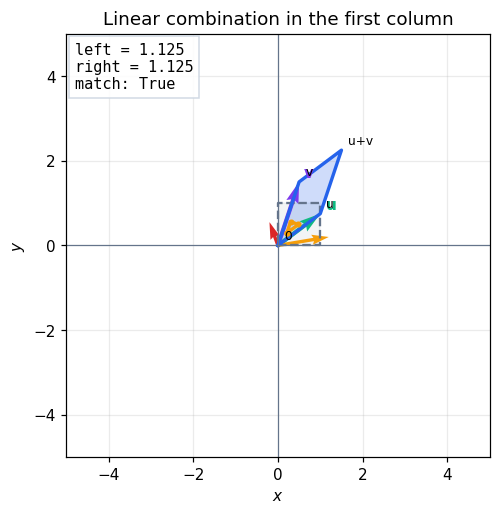

In [24]:
U_FIXED = np.array([1.2, .2])
V_FIXED = np.array([-.4, 1.1])
W_FIXED = np.array([.5, 1.5])

def multilinearity_experiment(alpha=1.0, beta=.5):
    first = alpha*U_FIXED + beta*V_FIXED
    A = np.column_stack([first, W_FIXED])
    lhs = det2(A)
    rhs = alpha*det2(np.column_stack([U_FIXED,W_FIXED])) + beta*det2(np.column_stack([V_FIXED,W_FIXED]))
    fig, ax = plt.subplots(figsize=(5.8, 5))
    draw_map(ax, A, limit=5, title="Linear combination in the first column")
    ax.quiver([0,0], [0,0], [alpha*U_FIXED[0], beta*V_FIXED[0]],
              [alpha*U_FIXED[1], beta*V_FIXED[1]], angles="xy", scale_units="xy", scale=1,
              color=[ORANGE, RED], width=.008)
    ax.text(.02,.98, f"left = {lhs:.3f}\nright = {rhs:.3f}\nmatch: {np.isclose(lhs,rhs)}",
            transform=ax.transAxes, va="top", family="monospace",
            bbox=dict(facecolor="white", alpha=.88, edgecolor="#cbd5e1"))
    plt.show(); plt.close(fig)

multilinearity_experiment()

In [25]:
_multi_output = show_widget(multilinearity_experiment, {
    "alpha": widgets.FloatSlider(value=1, min=-2, max=2, step=.1, description="α", continuous_update=False),
    "beta": widgets.FloatSlider(value=.5, min=-2, max=2, step=.1, description="β", continuous_update=False)
})

### Two common traps

**False identity.** In general, $\det(A+B)\ne\det A+\det B$. Take $A=B=I_2$:

$$\det(A+B)=\det(2I_2)=4,\qquad \det A+\det B=2.$$

**Scaling one column versus the whole matrix.** Scaling one column by $c$ multiplies the determinant by $c$. Scaling an $n\times n$ matrix by $c$ scales all $n$ columns, so

$$\det(cA)=c^n\det A.$$

In [26]:
A = np.eye(2); B = np.eye(2)
print("False additivity counterexample:", np.linalg.det(A+B), "!=", np.linalg.det(A)+np.linalg.det(B))

rng = np.random.default_rng(12)
M3 = rng.normal(size=(3,3)); c = -1.7
print("Whole-matrix scaling in 3D:",
      np.isclose(np.linalg.det(c*M3), c**3*np.linalg.det(M3)))

False additivity counterexample: 4.0 != 2.0
Whole-matrix scaling in 3D: True


An algebraic reason for multilinearity in 2D is direct expansion:

$$
\det[\alpha\mathbf u+\beta\mathbf v,\mathbf w]
=(\alpha u_x+\beta v_x)w_y-(\alpha u_y+\beta v_y)w_x,
$$

then collect the $\alpha$ and $\beta$ terms.

**Takeaway.** The determinant is linear in one chosen row or column while the others stay fixed—not in the matrix as a whole.

# Student activities: predict, then build

Use the general explorer or the interpretable controls. Write down your prediction before moving a slider.

1. **Construct determinant $2$.** Find a $2\times2$ matrix with signed area scale factor $2$.
2. **Preserve area while reversing orientation.** Construct a matrix with $|\det A|=1$ and $\det A<0$.
3. **Make the matrix singular.** Make two columns dependent.
4. **Change shape without changing determinant.** Start from $I$ and deform the square while keeping determinant $1$.
5. **Inverse challenge.** Construct a matrix whose inverse has determinant $4$.

Try more than one solution when possible. The suggested answers are deliberately placed below.

<details>
<summary><strong>Suggested answers</strong></summary>

1. $A=\operatorname{diag}(2,1)$ has $\det A=2$.
2. $A=\operatorname{diag}(-1,1)$ has determinant $-1$: area is preserved and orientation reverses.
3. $A=\begin{bmatrix}1&2\\1&2\end{bmatrix}$ has dependent columns and determinant $0$.
4. $A=\begin{bmatrix}1&k\\0&1\end{bmatrix}$ for any $k\ne0$ is a nontrivial shear with determinant $1$.
5. We need $\det(A^{-1})=4$, so $\det A=\tfrac14$. One choice is $A=\operatorname{diag}(\tfrac14,1)$.

</details>

# Summary: ten determinant properties

| # | Property | Geometric / algebraic meaning |
|---:|---|---|
| 1 | $\det I=1$ | Identity preserves signed area. |
| 2 | $\det A^\top=\det A$ | Transpose may change shape, not signed volume. |
| 3 | Swap two rows or columns $\Rightarrow$ negate determinant | Ordered orientation reverses. |
| 4 | Scale one row or column by $c$ $\Rightarrow$ scale determinant by $c$ | One directional scale changes signed volume by $c$. |
| 5 | Add a multiple of another row or column $\Rightarrow$ no change | Shear preserves base-height volume. |
| 6 | Dependent rows or columns $\Rightarrow\det A=0$; for square $A$, iff singular | Dimension collapses. |
| 7 | Triangular $A$: $\det A=\prod_i a_{ii}$ | Off-diagonal shear does not affect volume. |
| 8 | $\det(AB)=\det A\det B$ | Successive signed scale factors multiply. |
| 9 | $\det(A^{-1})=1/\det A$ | The inverse cancels the scale factor. |
| 10 | Linear in one row or column at a time | Weighted vector sums split signed volume linearly. |

## Final perspective

The determinant is not merely a formula. It is the signed factor by which a linear map scales area, volume, or $n$-dimensional volume. Elementary operations, composition, singularity, and inverses all become coherent when viewed through that lens.

> Numerical experiments make identities visible and test examples; they are not proofs. The short algebraic arguments in each section explain why the identities hold generally.